This notebook repdocues the results presented through Figure 4 and Figure 5.

In [10]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import jax
import jax.numpy as jnp
import numpyro
from numpyro.infer import MCMC, NUTS, Predictive
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Import helper function from the src directory
from src.inference.runner import run_parametric_mcmc

# Import models from the src directory
from src.models import (
    normal_model,
    contaminated_normal_model,
    student_t_model,
    bayesian_bootstrap_mean,
    bayesian_bootstrap_trimmed
)

# Import data from the data directory
data = jnp.load('../data/toy_dataset.npy')

# Figure 4
We smoothly vary the location of the sixth data point from x=0 to x=25, and observe how the credible intervals change for all five approaches.

In [11]:
# 1. Define the range
base_data = data[:-1]
outlier_values = np.linspace(0, 25, 26)

# 2. Storage
results = []

# 3. Run the loop
for val in outlier_values:
    # Update the data
    current_data = jnp.append(base_data, val)

    # Run Parametric Models (MCMC)
    mu_normal = run_parametric_mcmc(normal_model, current_data)["mu"]
    mu_contaminated = run_parametric_mcmc(contaminated_normal_model, current_data)["mu"]
    mu_student = run_parametric_mcmc(student_t_model, current_data)["mu"]

    # Run Nonparametric Models (Predictive)
    predictive_bb_mean = Predictive(bayesian_bootstrap_mean, num_samples=4000)
    mu_bb_mean = predictive_bb_mean(jax.random.PRNGKey(int(val)), current_data)["mu"]

    predictive_bb_trim = Predictive(bayesian_bootstrap_trimmed, num_samples=4000)
    mu_bb_trim = predictive_bb_trim(jax.random.PRNGKey(int(val)+1), current_data)["mu"]

    # Store Results
    for model_name, samples in zip(
        ["Normal model", "Contaminated normal model", "t-distribution", "BB mean", "BB trimmed mean"],
        [mu_normal, mu_contaminated, mu_student, mu_bb_mean, mu_bb_trim]
    ):
        results.append({
            "outlier": val,
            "model": model_name,
            "mean": np.mean(samples),
            "ci_lower": np.percentile(samples, 2.5),
            "ci_upper": np.percentile(samples, 97.5)
        })

df = pd.DataFrame(results)


sample: 100%|██████████| 5000/5000 [00:01<00:00, 4701.34it/s, 5 steps of size 5.60e-01. acc. prob=0.87]


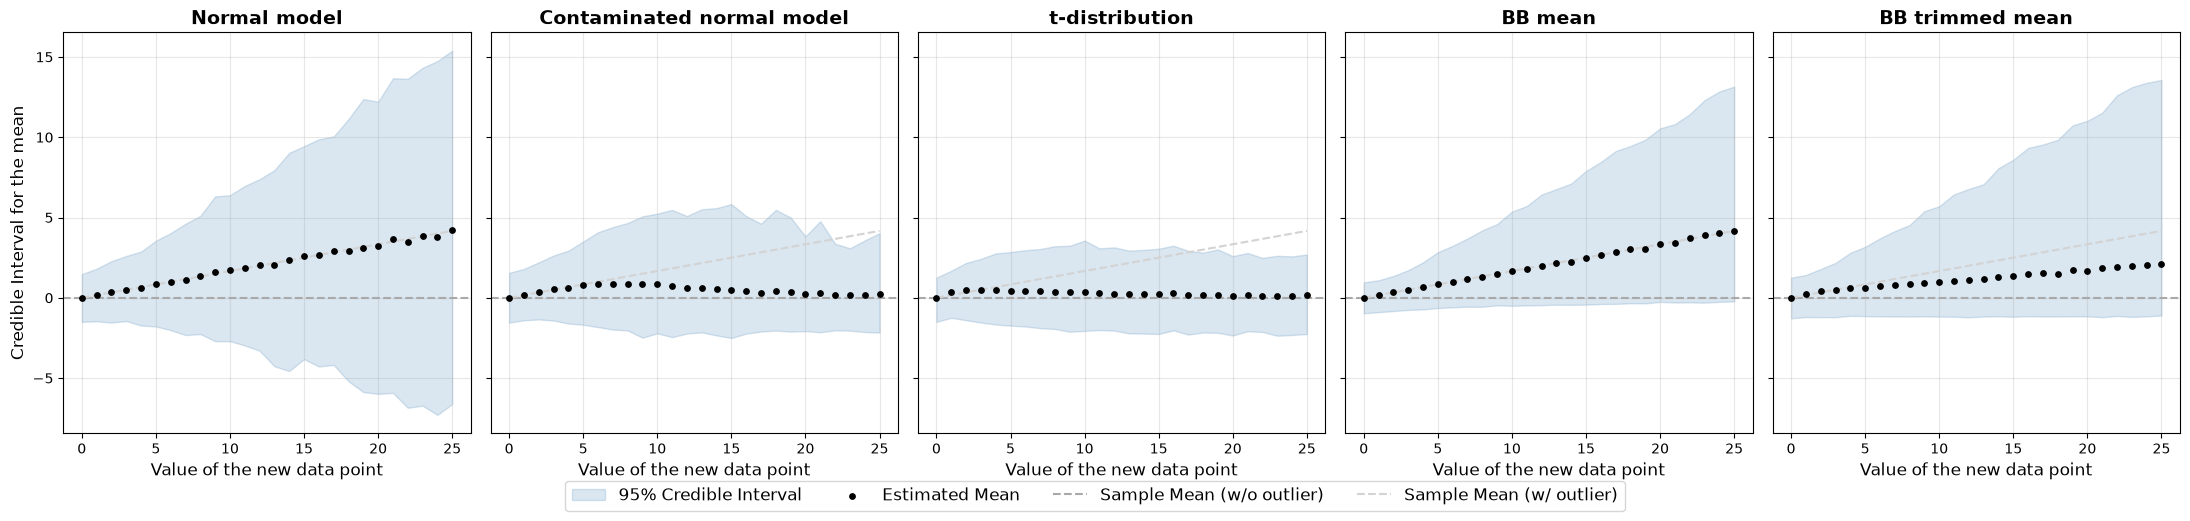

In [12]:
# Calculate the mean of the sample without the outlier
mean_no_outlier = jnp.mean(base_data)

# Calculate the mean of the sample including the outlier
mean_with_outlier = (jnp.sum(base_data) + outlier_values) / (len(base_data) + 1)

# Get unique models
models = df["model"].unique()

# Create a 1x5 grid of plots sharing the same y-axis
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

for ax, model_name in zip(axes, models):
    # Filter dataframe for the current model
    model_df = df[df["model"] == model_name]
    
    # 1. Shaded area depicting the credible interval
    ax.fill_between(
        model_df["outlier"], 
        model_df["ci_lower"], 
        model_df["ci_upper"], 
        color='steelblue', 
        alpha=0.2,
        label="95% Credible Interval"
    )
    
    # 2. Dark points showing the population mean estimated by the model
    ax.scatter(
        model_df["outlier"], 
        model_df["mean"], 
        color='black', 
        s=15, 
        zorder=3, 
        label="Estimated Mean"
    )
    
    # 3. Light grey dashed line: mean without the extreme point
    ax.axhline(
        mean_no_outlier, 
        color='darkgrey', 
        linestyle='--', 
        label="Sample Mean (w/o outlier)"
    )
    
    # 4. Light grey dashed line: mean WITH the extreme point
    ax.plot(
        outlier_values, 
        mean_with_outlier, 
        color='lightgrey', 
        linestyle='--', 
        label="Sample Mean (w/ outlier)"
    )
    
    # Formatting
    ax.set_title(f"{model_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Value of the new data point", fontsize=12)
    ax.grid(alpha=0.3)

# Axes labels and legend
axes[0].set_ylabel("Credible Interval for the mean", fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05), fontsize=12)

plt.tight_layout()
plt.show()


# Figure 5
We now consider how the models make different inferences as a function of sample size.

In [13]:
# 1. Define the range
sample_multipliers = np.arange(1, 16)
base_data = data

# 2. Storage
results_fig5 = []

# 3. Run the loop

for k in sample_multipliers:
    # Tile the data to strictly preserve the 16.6% contamination
    data = jnp.tile(base_data, k)
    N = len(data)
    
    # --- 1. Parametric Models (MCMC) ---
    # Double-check that 'data' (not base_data) is passed here!
    mu_normal = run_parametric_mcmc(normal_model, data, num_samples=4000)["mu"]
    mu_student = run_parametric_mcmc(student_t_model, data, num_samples=4000)["mu"]
    mu_contam = run_parametric_mcmc(contaminated_normal_model, data, num_samples=4000)["mu"]
    
    # --- 2. Nonparametric Models (Predictive) ---
    pred_bb_mean = Predictive(bayesian_bootstrap_mean, num_samples=4000)
    mu_bb_mean = pred_bb_mean(jax.random.PRNGKey(k), data)["mu"]
    
    pred_bb_trim = Predictive(bayesian_bootstrap_trimmed, num_samples=4000)
    mu_bb_trim = pred_bb_trim(jax.random.PRNGKey(k + 100), data)["mu"]
    
    # --- 3. Store Results ---
    for model_name, samples in zip(
        ["Normal model", "Contaminated normal model", "t-distribution", "BB mean", "BB trimmed mean"],
        [mu_normal, mu_student, mu_contam, mu_bb_mean, mu_bb_trim]
    ):
        results_fig5.append({
            "N": N,
            "model": model_name,
            "mean": np.mean(samples),
            "ci_lower": np.percentile(samples, 2.5),
            "ci_upper": np.percentile(samples, 97.5)
        })

df_fig5 = pd.DataFrame(results_fig5)


sample: 100%|██████████| 5000/5000 [00:01<00:00, 2830.99it/s, 15 steps of size 2.77e-01. acc. prob=0.95]


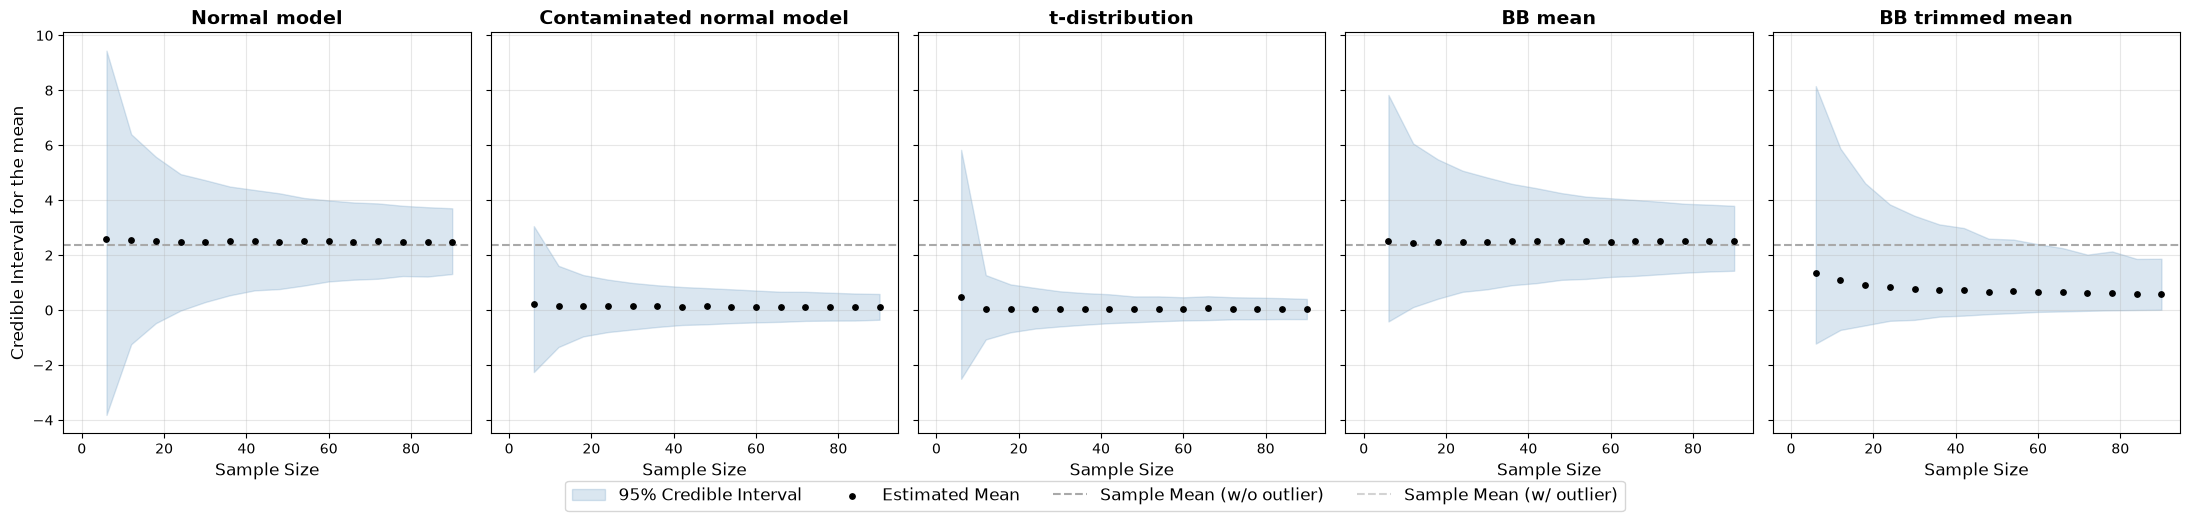

In [14]:
# Calculate the mean of the sample without the outlier
mean_no_outlier = jnp.mean(data[:-1])

# Calculate the mean of the sample including the outlier
mean_with_outlier = jnp.sum(data) / len(data)

# Get unique models
models = df_fig5["model"].unique()

# Create a 1x5 grid of plots sharing the same y-axis
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

for ax, model_name in zip(axes, models):
    # Filter dataframe for the current model
    model_df = df_fig5[df_fig5["model"] == model_name]
    
    # 1. Shaded area depicting the credible interval
    ax.fill_between(
        model_df["N"], 
        model_df["ci_lower"], 
        model_df["ci_upper"], 
        color='steelblue', 
        alpha=0.2,
        label="95% Credible Interval"
    )
    
    # 2. Dark points showing the population mean estimated by the model
    ax.scatter(
        model_df["N"], 
        model_df["mean"], 
        color='black', 
        s=15, 
        zorder=3, 
        label="Estimated Mean"
    )
    
    # 3. Light grey dashed line: mean without the extreme point
    ax.axhline(
        mean_no_outlier, 
        color='darkgrey', 
        linestyle='--', 
        label="Sample Mean (w/o outlier)"
    )
    
    # 4. Light grey dashed line: mean WITH the extreme point
    ax.plot(
        mean_with_outlier, 
        color='lightgrey', 
        linestyle='--', 
        label="Sample Mean (w/ outlier)"
    )
    
    # Formatting
    ax.set_title(f"{model_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Sample Size", fontsize=12)
    ax.grid(alpha=0.3)

# Axes labels and legend
axes[0].set_ylabel("Credible Interval for the mean", fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05), fontsize=12)

plt.tight_layout()
plt.show()
